In [1]:

# ============================
# Imports
# ============================
# gymnasium  : provides the RL environments (CartPole, Acrobot, LunarLander, Taxi)
# torch      : neural network framework used for policy and value networks
# torch.nn   : layer definitions and loss functions
# torch.optim: Adam optimizer for gradient updates
# numpy      : numerical operations and array handling for rewards/statistics
# matplotlib : plotting reward curves, entropy curves, and summary charts
# random     : used alongside numpy/torch for reproducible seeding

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random


In [2]:

# ============================
# Device Configuration
# ============================
# Automatically uses GPU if available (e.g. Colab T4), otherwise falls back to CPU.
# All tensors and models are moved to DEVICE during training.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================
# Hyperparameters
# ============================
# LR             : Adam learning rate for both policy and value networks
# GAMMA          : discount factor — how much future rewards are valued
# EPS_CLIP       : PPO clipping range [1-ε, 1+ε]; controls how much the policy can change per update
# EPOCHS         : default number of training epochs (overridden per environment in train())
# ROLLOUT_LENGTH : number of environment steps collected per epoch before updating
# UPDATE_EPOCHS  : number of passes over the collected rollout data per epoch
# ENTROPY_COEF   : weight of entropy bonus — encourages exploration
# MINIBATCH_SIZE : number of samples per minibatch during the update step
# LAMBDA         : GAE lambda — controls bias/variance tradeoff in advantage estimation
# USE_GAE        : if True, uses Generalized Advantage Estimation; if False, uses Monte Carlo returns

LR             = 3e-4
GAMMA          = 0.99
EPS_CLIP       = 0.2
EPOCHS         = 50
ROLLOUT_LENGTH = 4000
UPDATE_EPOCHS  = 10
ENTROPY_COEF   = 0.01
MINIBATCH_SIZE = 256
LAMBDA         = 0.95
USE_GAE        = True


Using device: cuda


In [3]:

# ============================
# Seed Utility
# ============================
# Ensures reproducibility across runs by fixing random state in Python, NumPy,
# and PyTorch, as well as the environment itself.
# Called once per training run before any interaction with the environment.

def set_seed(seed, env):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)


In [4]:

# ============================
# Networks
# ============================
# Both networks follow Schulman et al. (2017) Section 6.1:
# two hidden layers of 64 units with Tanh activations.
# Parameters are NOT shared between policy and value networks.
#
# PolicyNet : maps state -> action probability distribution (softmax output)
#             Used to sample actions and compute log-probabilities
#
# ValueNet  : maps state -> scalar value estimate V(s)
#             Used to compute advantages and returns

class PolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return torch.softmax(self.model(x), dim=-1)


class ValueNet(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)


In [5]:
# ============================
# Collect Rollout
# ============================
# Runs the current policy in the environment for `rollout_length` steps.
#
# discrete_obs  : if True, converts integer state to one-hot vector (used for Taxi-v3)
# torch.no_grad(): disables gradient tracking during rollout — inference only, no backprop
#
# Returns:
#   states          : tensor of observed states
#   actions         : tensor of actions taken
#   rewards         : tensor of rewards received
#   log_probs       : log-probabilities of actions under the old policy (used for ratio)
#   episode_returns : total return per completed episode (used for reward tracking)
#   dones           : episode termination flags (used in GAE and return computation)


def collect_rollout(env, policy, rollout_length, discrete_obs=False):
    states, actions, rewards, log_probs, dones = [], [], [], [], []
    episode_returns = []

    state, _ = env.reset()
    episode_return = 0

    for _ in range(rollout_length):
        if discrete_obs:
            state_tensor = torch.zeros(policy.model[0].in_features, device=DEVICE)
            state_tensor[state] = 1.0
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            probs = policy(state_tensor)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_p = dist.log_prob(action)

        next_state, reward, done, truncated, _ = env.step(action.item())

        states.append(state_tensor)
        actions.append(action.item())
        rewards.append(reward)
        log_probs.append(log_p)
        dones.append(done or truncated)

        episode_return += reward
        state = next_state

        if done or truncated:
            episode_returns.append(episode_return)
            episode_return = 0
            state, _ = env.reset()

    # Return all collected rollout data as tensors for use in GAE and update steps.
    return (
        torch.stack(states),                      # states : (T, state_dim)
        torch.LongTensor(actions).to(DEVICE),     # actions : (T,)
        torch.FloatTensor(rewards).to(DEVICE),    # rewards : (T,)
        torch.stack(log_probs),                   # log_probs : (T,)
        episode_returns,                          # episode_returns: list of floats
        torch.FloatTensor(dones).to(DEVICE),      # dones : (T,)
    )

In [6]:

# ============================
# Compute Returns (Monte Carlo)
# ============================
# Computes discounted cumulative returns G_t for each timestep.
# Traverses the rollout in reverse, resetting G to 0 at episode boundaries.
# Used when USE_GAE = False.
#
# Formula: G_t = r_t + γ * G_{t+1}

def compute_returns(rewards, dones, gamma):
    T = len(rewards)
    returns = torch.zeros(T, device=DEVICE)
    G = 0.0
    for t in reversed(range(T)):
        if dones[t]:
            G = 0.0
        G = rewards[t].item() + gamma * G
        returns[t] = G
    return returns


In [7]:

# ============================
# GAE Computation
# ============================
# Computes Generalized Advantage Estimation (GAE) following
# Schulman et al. (2015), Equations 11-12.
# Applied identically to both clipped and unclipped conditions.
#
# Variables:
#   mask       : 0 at episode boundaries (resets accumulation), 1 otherwise
#   delta      : TD error — δ_t = r_t + γ·V(s_{t+1})·mask - V(s_t)
#   last_adv   : accumulated advantage from future timesteps
#   values_ext : value estimates with a terminal 0 appended to avoid index errors
#
# Formula: Â_t = δ_t + (γλ)·mask·Â_{t+1}
#
# λ (LAMBDA) controls bias/variance tradeoff:
#   λ → 0 : low variance, high bias (closer to TD)
#   λ → 1 : low bias, high variance (closer to Monte Carlo)

def compute_gae(rewards, values, dones, gamma, lam):
    T = len(rewards)
    advantages = torch.zeros(T, device=DEVICE)
    last_adv = 0.0

    values_ext = torch.cat([values, torch.tensor([0.0], dtype=values.dtype, device=DEVICE)])

    for t in reversed(range(T)):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * values_ext[t + 1] * mask - values_ext[t]
        advantages[t] = last_adv = delta + gamma * lam * mask * last_adv

    return advantages


In [8]:

# ============================
# PPO Update Function
# ============================
# Performs policy and value network updates over multiple epochs of minibatches.
# This is where the clipped vs. unclipped distinction is implemented.
#
# Advantage normalization:
#   Normalized once at dataset level (zero mean, unit std) to reduce gradient variance.
#
# ratio:
#   r_t(θ) = exp(log π_θ(a|s) - log π_θ_old(a|s))
#   Measures how much the policy has changed from the data-collection policy.
#
# Clipped condition (use_clipping=True) — PPO: L_CLIP (Schulman et al. 2017, Eq. 7):
#   L_CLIP = E[min(r_t·Â, clip(r_t, 1-ε, 1+ε)·Â)]
#   Prevents ratio from moving outside [1-ε, 1+ε], bounding the policy update size.
#
# Unclipped condition (use_clipping=False) — L_CPI (Schulman et al. 2017, Eq. 6):
#   L_CPI = E[r_t·Â]
#   No constraint on the ratio — the ablation baseline from Table 1.
#
# Entropy bonus:
#   Encourages exploration by penalizing low-entropy (overly deterministic) policies.
#
# Value loss:
#   MSE between predicted V(s) and computed returns. Updated separately from policy.

mse_loss = nn.MSELoss()

def update(policy, value_net, optimizer_policy, optimizer_value,
           states, actions, old_log_probs, returns, advantages,
           use_clipping, update_epochs, minibatch_size, eps_clip, entropy_coef):

    entropy_value    = None
    value_loss_value = None
    dataset_size     = states.size(0)

    # Normalize advantages at dataset level
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    for _ in range(update_epochs):
        indices = torch.randperm(dataset_size)

        for start in range(0, dataset_size, minibatch_size):
            batch_idx = indices[start:start + minibatch_size]

            batch_states     = states[batch_idx]
            batch_actions    = actions[batch_idx]
            batch_old_lp     = old_log_probs[batch_idx]
            batch_returns    = returns[batch_idx]
            batch_advantages = advantages[batch_idx]

            # --- Policy Update ---
            probs = policy(batch_states)
            dist = torch.distributions.Categorical(probs)
            new_log_probs = dist.log_prob(batch_actions)
            ratio = torch.exp(new_log_probs - batch_old_lp)

            if use_clipping:
                # PPO clipped objective — L_CLIP
                clipped = torch.clamp(ratio, 1 - eps_clip, 1 + eps_clip)
                policy_loss = -torch.mean(torch.min(ratio * batch_advantages, clipped * batch_advantages))
            else:
                # Unclipped surrogate — L_CPI (ablation baseline)
                policy_loss = -torch.mean(ratio * batch_advantages)

            # Entropy bonus — encourages exploration
            entropy = dist.entropy().mean()
            policy_loss -= entropy_coef * entropy

            # --- Value Loss ---
            values = value_net(batch_states).squeeze()
            value_loss = mse_loss(values, batch_returns)

            # --- Backprop ---
            optimizer_policy.zero_grad()
            policy_loss.backward()
            optimizer_policy.step()

            optimizer_value.zero_grad()
            value_loss.backward()
            optimizer_value.step()

            entropy_value    = entropy.item()
            value_loss_value = value_loss.item()

    return entropy_value, value_loss_value


In [9]:
# ============================
# Train Function
# ============================
# Orchestrates the full training loop for one condition (clipped or unclipped)
# on one environment and one seed.
#
# Per-environment epoch counts:
#   CartPole    : 50  epochs (simple, converges quickly)
#   Acrobot     : 100 epochs (moderate difficulty)
#   LunarLander : 200 epochs (complex — uses 200 epochs to allow convergence)
#   Taxi        : 75  epochs (discrete sparse reward)
#
# Training loop per epoch:
#   1. collect_rollout : interact with environment for T steps
#   2. compute_gae     : compute advantage estimates
#   3. update          : optimize networks over K minibatch epochs
#   4. log metrics     : record reward, std, entropy, value loss

def train(env_name, use_clipping=True, seed=0,
          LR=LR, GAMMA=GAMMA, EPS_CLIP=EPS_CLIP,
          EPOCHS=EPOCHS, ROLLOUT_LENGTH=ROLLOUT_LENGTH,
          UPDATE_EPOCHS=UPDATE_EPOCHS, ENTROPY_COEF=ENTROPY_COEF,
          MINIBATCH_SIZE=MINIBATCH_SIZE, LAMBDA=LAMBDA,
          USE_GAE=USE_GAE):

    env = gym.make(env_name)
    set_seed(seed, env)

    # Per-environment training budget
    if env_name == "Acrobot-v1":
        epochs = EPOCHS + 50
    elif env_name == "LunarLander-v3":
        epochs = EPOCHS + 150   # Extended: requires longer training to converge
    elif env_name == "Taxi-v3":
        epochs = EPOCHS + 25
    else:
        epochs = EPOCHS

    # Handle discrete observation spaces (Taxi-v3) via one-hot encoding
    if isinstance(env.observation_space, gym.spaces.Discrete):
        state_dim = env.observation_space.n
        discrete_obs = True
    else:
        state_dim = env.observation_space.shape[0]
        discrete_obs = False

    action_dim = env.action_space.n

    policy    = PolicyNet(state_dim, action_dim).to(DEVICE)
    value_net = ValueNet(state_dim).to(DEVICE)

    optimizer_policy = optim.Adam(policy.parameters(), lr=LR)
    optimizer_value  = optim.Adam(value_net.parameters(), lr=LR)

    reward_history, entropy_history = [], []
    reward_std_history, value_loss_history = [], []

    for epoch in range(epochs):
        # Step 1: Collect rollout
        states, actions, rewards, old_log_probs, episode_returns, dones = \
            collect_rollout(env, policy, ROLLOUT_LENGTH, discrete_obs)

        # Step 2: Compute advantages and returns
        if USE_GAE:
            with torch.no_grad():
                values = value_net(states).squeeze()
            advantages = compute_gae(rewards, values, dones, GAMMA, LAMBDA)
            returns = advantages + values
        else:
            returns = compute_returns(rewards, dones, GAMMA)
            with torch.no_grad():
                advantages = returns - value_net(states).squeeze()

        # Step 3: Update networks
        entropy_value, value_loss_value = update(
            policy, value_net,
            optimizer_policy, optimizer_value,
            states, actions, old_log_probs,
            returns, advantages,
            use_clipping,
            UPDATE_EPOCHS, MINIBATCH_SIZE, EPS_CLIP, ENTROPY_COEF,
        )

        # Step 4: Log metrics
        avg_reward = np.mean(episode_returns)
        reward_std = np.std(episode_returns)

        reward_history.append(avg_reward)
        reward_std_history.append(reward_std)
        entropy_history.append(entropy_value)
        value_loss_history.append(value_loss_value)

    env.close()
    return reward_history, entropy_history, reward_std_history, value_loss_history

In [10]:

# ============================
# Smoothing Function
# ============================
# Applies a moving average to a sequence for cleaner plot visualization.
# mode='valid' means the output is shorter than input by (window-1) steps.
# SMOOTH_OFFSET in the plotting functions corrects for this x-axis shift.

def smooth(x, window=5):
    return np.convolve(x, np.ones(window) / window, mode='valid')


In [11]:

# ============================
# Summarization Function
# ============================
# Computes and prints three stability metrics per environment:
#
#   Final reward      : mean ± std of episode rewards in the last epoch across seeds
#   Late-training std : reward std over the last 20% of training epochs across all seeds
#                       lower = more stable convergence
#   Worst collapse    : minimum reward seen across any seed or epoch
#                       captures catastrophic policy failures

def summarize(vanilla_runs, ppo_runs, env_name):
    final_vanilla = vanilla_runs[:, -1]
    final_ppo     = ppo_runs[:, -1]

    # Late-training stability: std over last 20% of epochs
    tail = max(1, vanilla_runs.shape[1] // 5)
    vanilla_late_std = vanilla_runs[:, -tail:].std()
    ppo_late_std     = ppo_runs[:, -tail:].std()

    # Worst-case collapse across all seeds and epochs
    vanilla_min = vanilla_runs.min()
    ppo_min     = ppo_runs.min()

    result = {
        "env":              env_name,
        "vanilla_mean":     final_vanilla.mean(),
        "vanilla_std":      final_vanilla.std(),
        "ppo_mean":         final_ppo.mean(),
        "ppo_std":          final_ppo.std(),
        "improvement":      final_ppo.mean() - final_vanilla.mean(),
        "vanilla_late_std": vanilla_late_std,
        "ppo_late_std":     ppo_late_std,
        "vanilla_min":      vanilla_min,
        "ppo_min":          ppo_min,
    }

    print(f"\n=== {env_name} ===")
    print(f"  Final reward   — Unclipped: {result['vanilla_mean']:.2f} ± {result['vanilla_std']:.2f} | "
          f"PPO: {result['ppo_mean']:.2f} ± {result['ppo_std']:.2f}")
    print(f"  Late-train std — Unclipped: {result['vanilla_late_std']:.2f} | "
          f"PPO: {result['ppo_late_std']:.2f}  (lower = more stable)")
    print(f"  Worst collapse — Unclipped: {result['vanilla_min']:.2f} | "
          f"PPO: {result['ppo_min']:.2f}  (higher = fewer crashes)")

    return result


In [12]:

# ============================
# Plotting Helpers
# ============================
# SMOOTH_WINDOW : moving average window size
# SMOOTH_OFFSET : corrects x-axis labels after smoothing shortens the array

SMOOTH_WINDOW = 5
SMOOTH_OFFSET = (SMOOTH_WINDOW - 1) // 2  # = 2, centers x-axis labels correctly

def plot_rewards(ax, vanilla_runs, ppo_runs, env_name):
    """
    Reward curves for both conditions.
    Faint lines: individual seeds (exposes collapse events).
    Bold lines: smoothed mean. Shaded band: ±1 std across seeds.
    """
    vanilla_runs = np.array(vanilla_runs)
    ppo_runs     = np.array(ppo_runs)

    # Individual seed lines (faint)
    for run in vanilla_runs:
        s = smooth(run)
        ax.plot(range(SMOOTH_OFFSET, SMOOTH_OFFSET + len(s)), s, color="blue", alpha=0.15, linewidth=0.8)
    for run in ppo_runs:
        s = smooth(run)
        ax.plot(range(SMOOTH_OFFSET, SMOOTH_OFFSET + len(s)), s, color="red", alpha=0.15, linewidth=0.8)

    mean_v = smooth(vanilla_runs.mean(axis=0))
    mean_p = smooth(ppo_runs.mean(axis=0))
    std_v  = smooth(vanilla_runs.std(axis=0))
    std_p  = smooth(ppo_runs.std(axis=0))
    x_v    = range(SMOOTH_OFFSET, SMOOTH_OFFSET + len(mean_v))
    x_p    = range(SMOOTH_OFFSET, SMOOTH_OFFSET + len(mean_p))

    ax.plot(x_v, mean_v, label="Unclipped", color="blue", linewidth=2)
    ax.fill_between(x_v, mean_v - std_v, mean_v + std_v, alpha=0.2, color="blue")
    ax.plot(x_p, mean_p, label="PPO (Clipped)", color="red", linewidth=2)
    ax.fill_between(x_p, mean_p - std_p, mean_p + std_p, alpha=0.2, color="red")

    ax.set_title(f"{env_name} — Reward")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average Reward")
    ax.legend()


def plot_entropy(ax, vanilla_entropy, ppo_entropy, env_name):
    """
    Policy entropy over training for both conditions.
    A sudden drop in the unclipped condition signals premature policy collapse —
    the policy has become near-deterministic before sufficient exploration.
    PPO's clipping prevents this by bounding how aggressively the policy is updated.
    """
    vanilla_entropy = np.array(vanilla_entropy)
    ppo_entropy     = np.array(ppo_entropy)

    mean_v = smooth(vanilla_entropy.mean(axis=0))
    mean_p = smooth(ppo_entropy.mean(axis=0))
    std_v  = smooth(vanilla_entropy.std(axis=0))
    std_p  = smooth(ppo_entropy.std(axis=0))
    x      = range(SMOOTH_OFFSET, SMOOTH_OFFSET + len(mean_v))

    ax.plot(x, mean_v, label="Unclipped", color="blue", linewidth=2)
    ax.fill_between(x, mean_v - std_v, mean_v + std_v, alpha=0.2, color="blue")
    ax.plot(x, mean_p, label="PPO (Clipped)", color="red", linewidth=2)
    ax.fill_between(x, mean_p - std_p, mean_p + std_p, alpha=0.2, color="red")

    ax.set_title(f"{env_name} — Policy Entropy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Entropy")
    ax.legend()


In [13]:

# ============================
# Shared Training Loop
# ============================
# Runs both conditions (unclipped and clipped) across all seeds for one environment.
# Produces reward and entropy plots, then returns the summary dict.

def run_env(env_name):
    print(f"\n========== Environment: {env_name} ==========\n")
    NUM_SEEDS = 4
    vanilla_rewards, vanilla_entropy = [], []
    ppo_rewards,     ppo_entropy     = [], []

    for seed in range(NUM_SEEDS):
        print(f"Seed {seed} — Unclipped")
        r, e, _, _ = train(env_name, use_clipping=False, seed=seed)
        vanilla_rewards.append(r)
        vanilla_entropy.append(e)

        print(f"Seed {seed} — PPO (Clipped)")
        r, e, _, _ = train(env_name, use_clipping=True, seed=seed)
        ppo_rewards.append(r)
        ppo_entropy.append(e)

    vanilla_rewards = np.array(vanilla_rewards)
    ppo_rewards     = np.array(ppo_rewards)
    # Replace any None entropy values (can occur on very short rollouts) with 0
    vanilla_entropy = np.array([[v if v is not None else 0 for v in row] for row in vanilla_entropy])
    ppo_entropy     = np.array([[v if v is not None else 0 for v in row] for row in ppo_entropy])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{env_name}: PPO Clipping vs Unclipped — Stability Comparison", fontsize=13)
    plot_rewards(axes[0], vanilla_rewards, ppo_rewards, env_name)
    plot_entropy(axes[1], vanilla_entropy, ppo_entropy, env_name)
    plt.tight_layout()
    plt.show()

    return summarize(vanilla_rewards, ppo_rewards, env_name)


In [14]:

# ============================
# Summary Plot — All Environments
# ============================
# Two-panel bar chart summarizing results across all environments:
#   Left  : Final reward (mean ± std) — overall performance
#   Right : Late-training reward std  — stability (lower = more stable)

def plot_all_environments(results):
    envs = list(results.keys())
    x    = np.arange(len(envs))

    vanilla_means = [results[e]["vanilla_mean"]     for e in envs]
    ppo_means     = [results[e]["ppo_mean"]         for e in envs]
    vanilla_std   = [results[e]["vanilla_std"]      for e in envs]
    ppo_std       = [results[e]["ppo_std"]          for e in envs]
    vanilla_late  = [results[e]["vanilla_late_std"] for e in envs]
    ppo_late      = [results[e]["ppo_late_std"]     for e in envs]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Summary Across Environments", fontsize=13)

    # Left: Final reward
    axes[0].bar(x - 0.2, vanilla_means, width=0.4, label="Unclipped",     yerr=vanilla_std, capsize=4)
    axes[0].bar(x + 0.2, ppo_means,     width=0.4, label="PPO (Clipped)", yerr=ppo_std,     capsize=4)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(envs, rotation=15)
    axes[0].set_ylabel("Final Reward (Mean ± Std)")
    axes[0].set_title("Final Performance")
    axes[0].legend()

    # Right: Late-training stability (lower = more stable)
    axes[1].bar(x - 0.2, vanilla_late, width=0.4, label="Unclipped",     color="steelblue")
    axes[1].bar(x + 0.2, ppo_late,     width=0.4, label="PPO (Clipped)", color="tomato")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(envs, rotation=15)
    axes[1].set_ylabel("Reward Std (last 20% of training)")
    axes[1].set_title("Training Stability (lower = more stable)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [15]:

# =================================
# Environment Testing - CartPole-v1
# =================================

def run_cartpole():
    return run_env("CartPole-v1")


In [16]:

# =================================
# Environment Testing - Acrobot-v1
# =================================

def run_acrobot():
    return run_env("Acrobot-v1")


In [17]:

# =================================
# Environment Testing - LunarLander-v3
# =================================

def run_lunarlander():
    return run_env("LunarLander-v3")


In [18]:

# =================================
# Environment Testing - Taxi-v3
# =================================

def run_taxi():
    return run_env("Taxi-v3")


In [19]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 62.3 MB/s eta 0:00:00


In [20]:
RUN_TAXI = True
RUN_CARTPOLE = True
RUN_ACROBAT = True
RUN_LUNAR = True

In [21]:
def main():
    results = {}

    if RUN_CARTPOLE:
        results["CartPole-v1"] = run_cartpole()

    if RUN_ACROBAT:
        results["Acrobot-v1"] = run_acrobot()

    if RUN_LUNAR:
        results["LunarLander-v3"] = run_lunarlander()

    if RUN_TAXI:
        results["Taxi-v3"] = run_taxi()

    plot_all_environments(results)


========== Environment: CartPole-v1 ==========

Seed 0 — Unclipped
Seed 0 — PPO (Clipped)
Seed 1 — Unclipped
Seed 1 — PPO (Clipped)
Seed 2 — Unclipped
Seed 2 — PPO (Clipped)
Seed 3 — Unclipped
Seed 3 — PPO (Clipped)


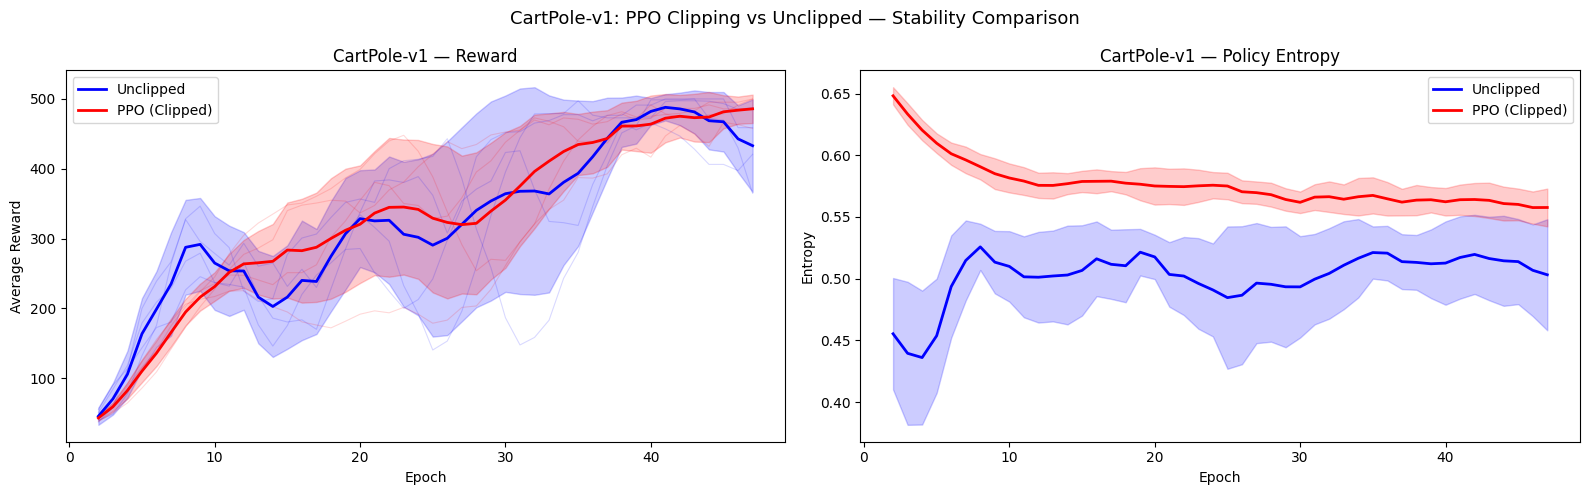


=== CartPole-v1 ===
  Final reward   — Unclipped: 418.77 ± 140.69 | PPO: 488.91 ± 19.21
  Late-train std — Unclipped: 74.77 | PPO: 34.29  (lower = more stable)
  Worst collapse — Unclipped: 22.43 | PPO: 22.43  (higher = fewer crashes)

========== Environment: Acrobot-v1 ==========

Seed 0 — Unclipped
Seed 0 — PPO (Clipped)
Seed 1 — Unclipped
Seed 1 — PPO (Clipped)
Seed 2 — Unclipped
Seed 2 — PPO (Clipped)
Seed 3 — Unclipped
Seed 3 — PPO (Clipped)


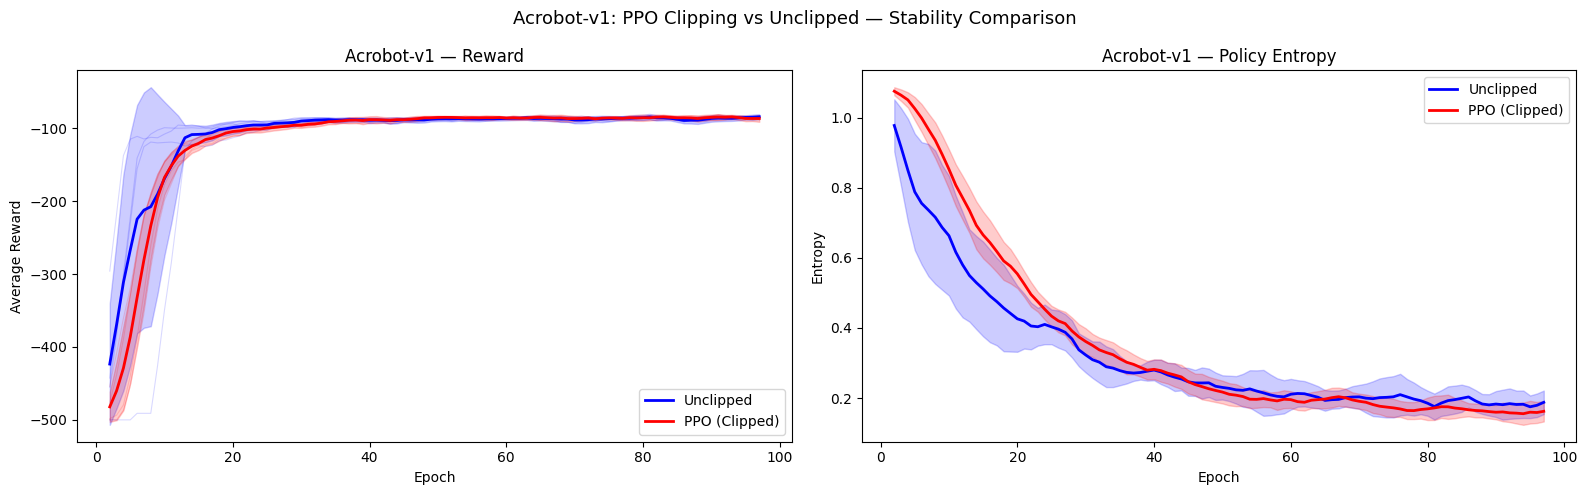


=== Acrobot-v1 ===
  Final reward   — Unclipped: -83.79 ± 1.20 | PPO: -86.66 ± 6.92
  Late-train std — Unclipped: 4.90 | PPO: 4.44  (lower = more stable)
  Worst collapse — Unclipped: -500.00 | PPO: -500.00  (higher = fewer crashes)

========== Environment: LunarLander-v3 ==========

Seed 0 — Unclipped
Seed 0 — PPO (Clipped)
Seed 1 — Unclipped
Seed 1 — PPO (Clipped)
Seed 2 — Unclipped
Seed 2 — PPO (Clipped)
Seed 3 — Unclipped
Seed 3 — PPO (Clipped)


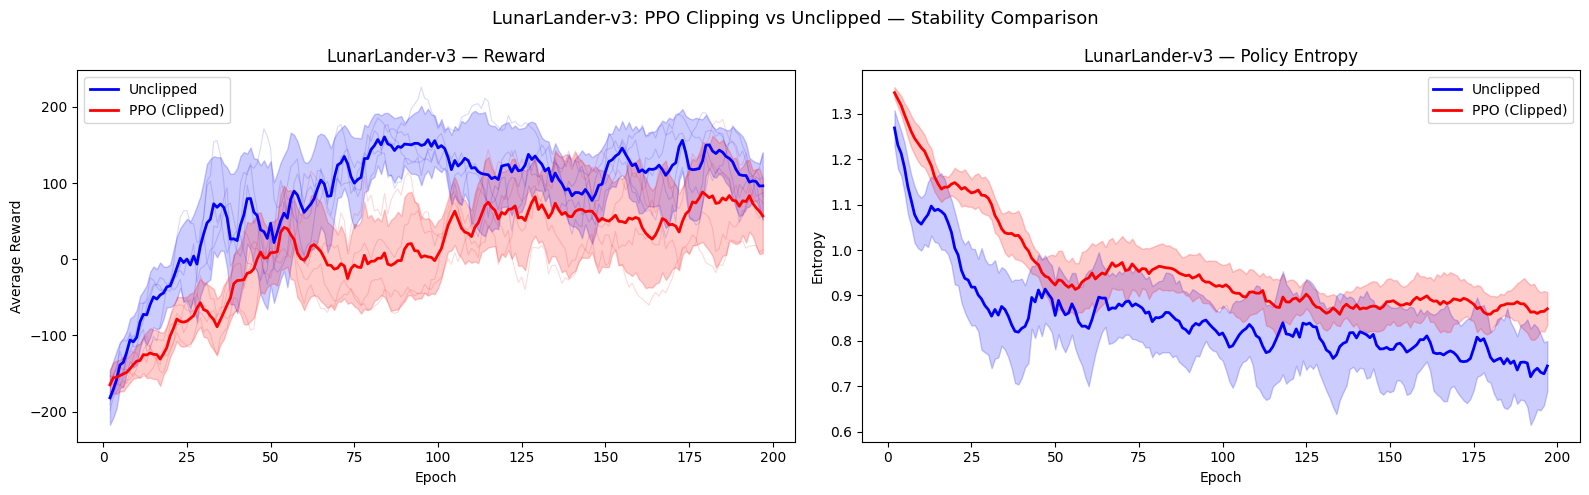


=== LunarLander-v3 ===
  Final reward   — Unclipped: 109.03 ± 85.24 | PPO: 56.78 ± 34.65
  Late-train std — Unclipped: 60.47 | PPO: 70.52  (lower = more stable)
  Worst collapse — Unclipped: -306.39 | PPO: -216.36  (higher = fewer crashes)

========== Environment: Taxi-v3 ==========

Seed 0 — Unclipped
Seed 0 — PPO (Clipped)
Seed 1 — Unclipped
Seed 1 — PPO (Clipped)
Seed 2 — Unclipped
Seed 2 — PPO (Clipped)
Seed 3 — Unclipped
Seed 3 — PPO (Clipped)


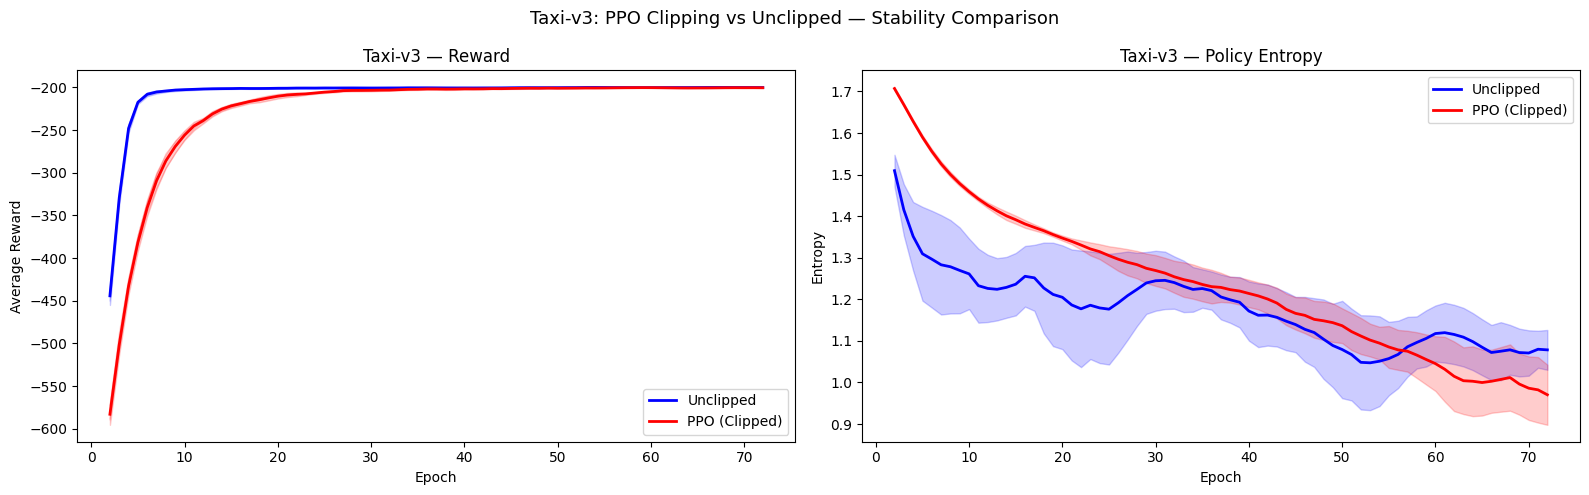


=== Taxi-v3 ===
  Final reward   — Unclipped: -200.45 ± 0.32 | PPO: -200.67 ± 0.23
  Late-train std — Unclipped: 0.31 | PPO: 0.44  (lower = more stable)
  Worst collapse — Unclipped: -807.50 | PPO: -807.50  (higher = fewer crashes)


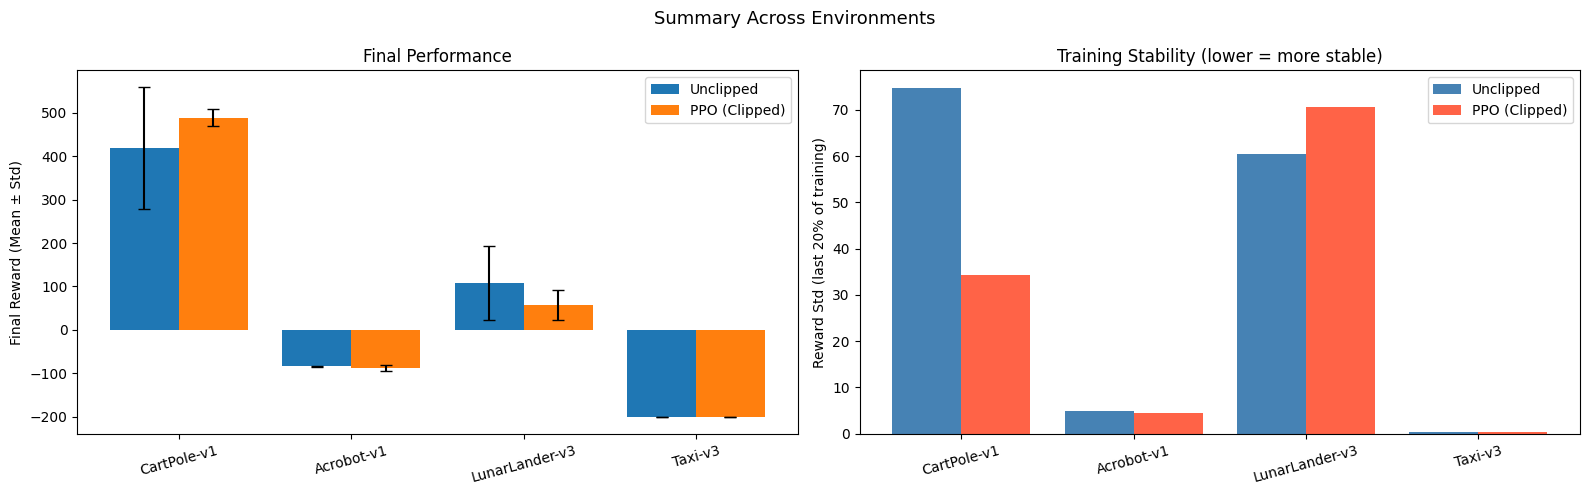

In [22]:
if __name__ == "__main__":
    main()